# Step 1 + Step 2 Post-Profiling Analysis — REV Buffer-Likelihood Fast Path

**Date:** 2026-04-11  
**Benchmark:** `results/2026_04_11_after_rev_prof/`  
**Baseline:** `results/2026_04_03_fulltets_withouttree/DNA/` (CPU 1/10/48 threads + GPU V100)  
**Kernels:** REV (eigenspace) and NONREV (state-space)  
**Workload:** DNA, 100 taxa, full ModelFinder + NNI tree search, alignment lengths 100 / 1 000 / 10 000 / 100 000 sites

This notebook walks through the Step 1 / Step 2 results, compares them against the 2026-04-03 CPU + GPU baseline, and identifies where the buffer-likelihood fast path helps vs. regresses.

## 1. Load data

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.float_format', lambda v: f'{v:,.2f}')

HERE = os.getcwd()

BASE_COLS = ['len', 'kernel', 'backend', 'fml_s', 'mf_s', 'ts_s', 'total_s',
             'cpu_s', 'lnl', 'iters']
STEP_COLS = ['len', 'label', 'fml_s', 'mf_s', 'ts_s', 'total_s',
             'cpu_s', 'lnl', 'iters']

baseline = pd.read_csv(os.path.join(HERE, 'baseline_2026-04-03.csv'),
                       header=None, names=BASE_COLS)
step12   = pd.read_csv(os.path.join(HERE, 'step12_metrics.csv'),
                       header=None, names=STEP_COLS)

baseline['nlen'] = baseline['len'].str.replace('len_', '').astype(int)
step12['nlen']   = step12['len'].str.replace('len_', '').astype(int)
step12[['kernel', 'step']] = step12['label'].str.split('_', expand=True)

print('Baseline:', len(baseline), 'rows')
print('Step 1/2:', len(step12), 'rows')

Baseline: 32 rows
Step 1/2: 16 rows


## 2. 2026-04-03 baseline — CPU and GPU wall times

Full tree search (no `-te`), REV and NONREV kernels, across four alignment lengths. Total wall-clock time in seconds.

In [2]:
pivot = baseline.pivot_table(
    index=['nlen', 'kernel'],
    columns='backend',
    values='total_s',
    aggfunc='first',
)[['CPU_1', 'CPU_10', 'CPU_48', 'GPU_V100']]
pivot

backend           CPU_1   CPU_10   CPU_48  GPU_V100
nlen   kernel                                      
100    NONREV     33.89    54.31    94.25    484.64
       REV        21.31   109.58   277.33    479.35
1000   NONREV    101.00   104.18   246.72    290.33
       REV        83.32    47.60   255.77    295.56
10000  NONREV  1,015.93   329.61   291.77    318.39
       REV       898.37   236.59   295.29    335.86
100000 NONREV 10,938.18 2,816.23 1,226.24    988.46
       REV     9,299.01 1,429.38   967.30    985.99

**Reading the baseline:** at short alignments the CPU wins handily (the 1-thread VANILA run beats the V100 22× at `len_100` because kernel launch latency dominates on 100 patterns). At long alignments the GPU is competitive with 48-core CPU (`len_100000`: V100 ~986 s vs CPU_48 ~967 s). The crossover is around `len_10000` where CPU_10 wins outright.

## 3. CPU vs GPU baseline — log-log lines

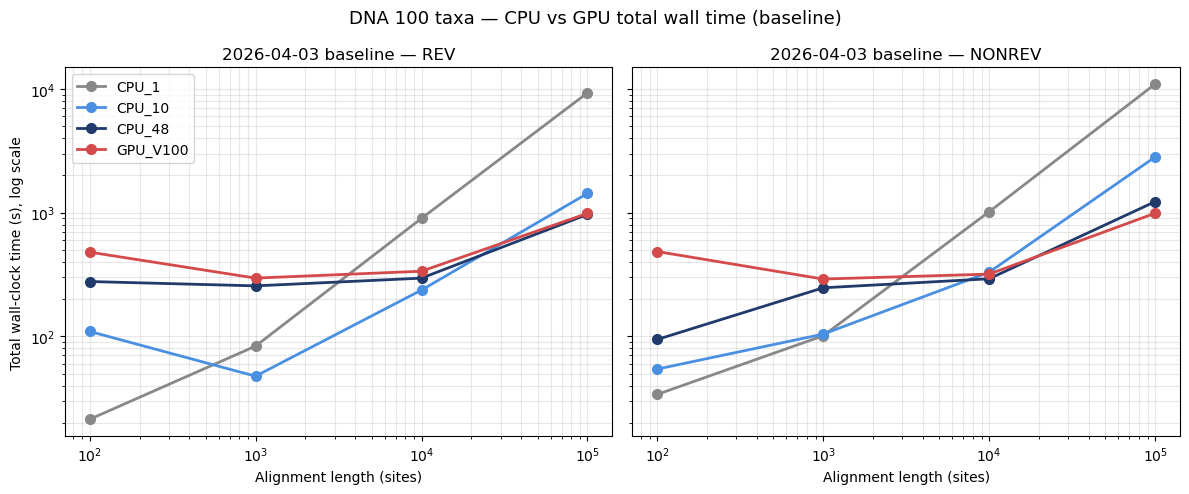

In [3]:
BACKEND_COLORS = {'CPU_1': '#888888', 'CPU_10': '#4a90e2',
                  'CPU_48': '#1f3a6b', 'GPU_V100': '#d44a4a'}

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, kernel in zip(axes, ['REV', 'NONREV']):
    for backend in ['CPU_1', 'CPU_10', 'CPU_48', 'GPU_V100']:
        sub = baseline[(baseline.kernel == kernel) &
                       (baseline.backend == backend)].sort_values('nlen')
        if sub.empty:
            continue
        ax.plot(sub.nlen, sub.total_s, 'o-', label=backend,
                color=BACKEND_COLORS[backend], linewidth=2, markersize=7)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('Alignment length (sites)')
    ax.set_title(f'2026-04-03 baseline — {kernel}')
    ax.grid(True, which='both', alpha=0.3)
axes[0].set_ylabel('Total wall-clock time (s), log scale')
axes[0].legend(loc='best', frameon=True)
fig.suptitle('DNA 100 taxa — CPU vs GPU total wall time (baseline)', fontsize=13)
fig.tight_layout()
plt.show()

## 4. Step 1 and Step 2 — 2026-04-11 GPU results

Both kernels were rerun with Step 1 (`theta_all` GPU residency) and Step 2 (`computeLikelihoodFromBufferRevOpenACC` fast path). NONREV is the control — neither step changes the NONREV dispatch, so NONREV deltas measure run-to-run noise.

In [4]:
step_pivot = step12.pivot_table(
    index=['nlen', 'kernel'],
    columns='step',
    values='total_s',
    aggfunc='first',
)
step_pivot['Δ (s)']   = step_pivot['Step2'] - step_pivot['Step1']
step_pivot['Δ (%)']   = (step_pivot['Step2'] / step_pivot['Step1'] - 1) * 100
step_pivot

step           Step1  Step2  Δ (s)  Δ (%)
nlen   kernel                            
100    NONREV 481.99 483.29   1.31   0.27
       REV    467.54 478.72  11.18   2.39
1000   NONREV 303.19 309.12   5.93   1.96
       REV    291.47 290.49  -0.98  -0.34
10000  NONREV 336.73 331.91  -4.81  -1.43
       REV    370.94 330.27 -40.67 -10.96
100000 NONREV 990.62 995.00   4.38   0.44
       REV    832.11 947.62 115.50  13.88

**Observations:**

- **NONREV noise ceiling: ±2%.** The NONREV deltas span `-1.43%` to `+1.96%` — this is pure run-to-run noise across different V100 nodes.
- **REV signals outside noise:**
  - `len_100`: **+2.4%** (mild regression)
  - `len_10000`: **−11.0%** (genuine win — the projected speedup delivered)
  - `len_100000`: **+13.9%** (significant regression)

## 5. Step 1 vs Step 2 — grouped bars

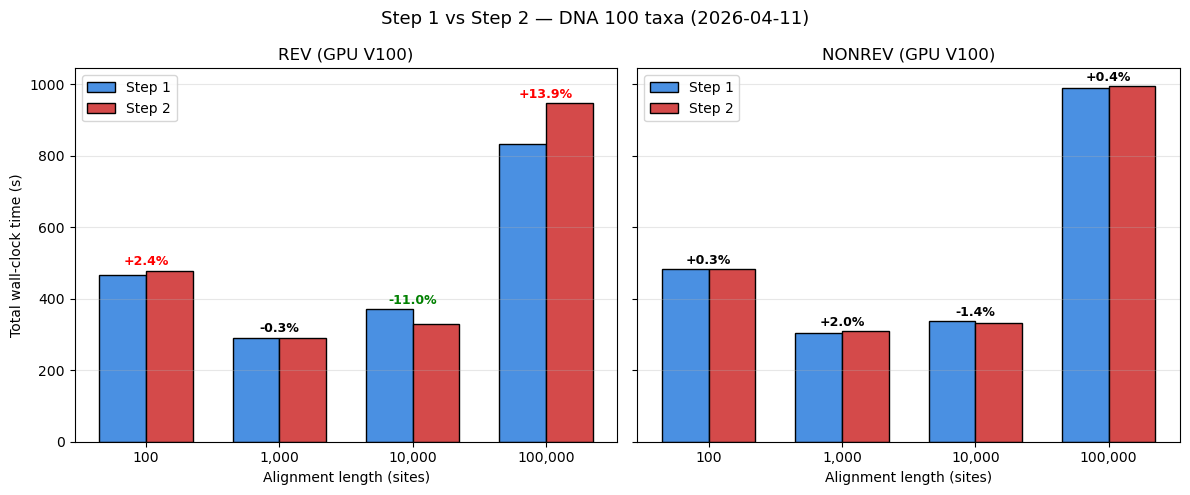

In [5]:
STEP_COLORS = {'Step1': '#4a90e2', 'Step2': '#d44a4a'}
LENGTHS = [100, 1000, 10000, 100000]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
x = np.arange(len(LENGTHS))
width = 0.35

for ax, kernel in zip(axes, ['REV', 'NONREV']):
    s1_vals, s2_vals = [], []
    for L in LENGTHS:
        s1 = step12[(step12.nlen == L) & (step12.kernel == kernel) &
                    (step12.step == 'Step1')].total_s.values
        s2 = step12[(step12.nlen == L) & (step12.kernel == kernel) &
                    (step12.step == 'Step2')].total_s.values
        s1_vals.append(s1[0] if len(s1) else np.nan)
        s2_vals.append(s2[0] if len(s2) else np.nan)

    ax.bar(x - width/2, s1_vals, width, label='Step 1',
           color=STEP_COLORS['Step1'], edgecolor='black')
    ax.bar(x + width/2, s2_vals, width, label='Step 2',
           color=STEP_COLORS['Step2'], edgecolor='black')

    for i, (s1, s2) in enumerate(zip(s1_vals, s2_vals)):
        if not (np.isnan(s1) or np.isnan(s2)):
            pct = (s2 - s1) / s1 * 100
            col = 'red' if pct > 2 else ('green' if pct < -2 else 'black')
            ax.annotate(f'{pct:+.1f}%', xy=(i, max(s1, s2) + 15),
                        ha='center', fontsize=9, color=col, fontweight='bold')

    ax.set_xticks(x); ax.set_xticklabels([f'{L:,}' for L in LENGTHS])
    ax.set_xlabel('Alignment length (sites)')
    ax.set_title(f'{kernel} (GPU V100)')
    ax.grid(True, axis='y', alpha=0.3); ax.legend(loc='upper left')
axes[0].set_ylabel('Total wall-clock time (s)')
fig.suptitle('Step 1 vs Step 2 — DNA 100 taxa (2026-04-11)', fontsize=13)
fig.tight_layout()
plt.show()

## 6. Δ% (Step 2 / Step 1 − 1) with NONREV noise band

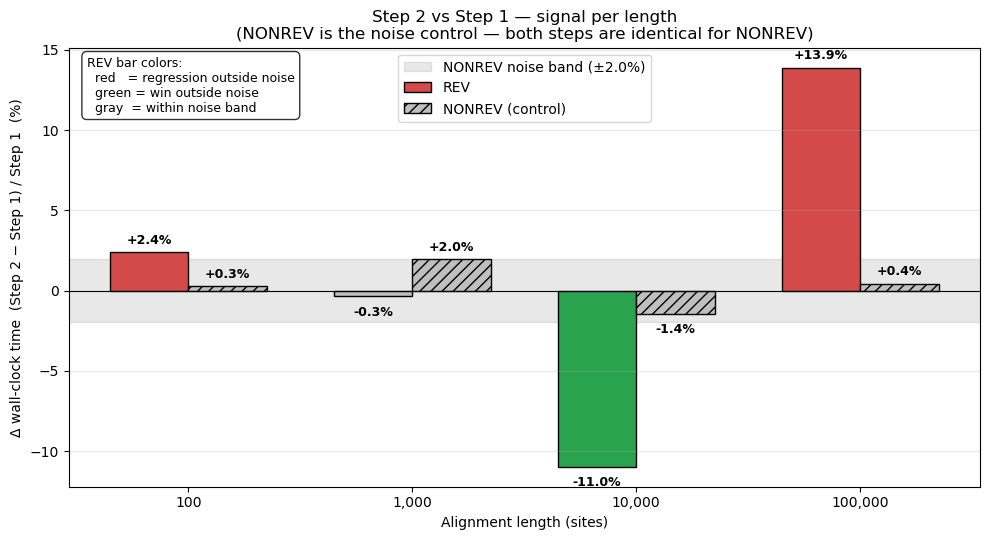

In [6]:
fig, ax = plt.subplots(figsize=(10, 5.5))
x = np.arange(len(LENGTHS))
width = 0.35

rev_delta, nonrev_delta = [], []
for L in LENGTHS:
    for kernel, bucket in [('REV', rev_delta), ('NONREV', nonrev_delta)]:
        s1 = step12[(step12.nlen == L) & (step12.kernel == kernel) &
                    (step12.step == 'Step1')].total_s.values
        s2 = step12[(step12.nlen == L) & (step12.kernel == kernel) &
                    (step12.step == 'Step2')].total_s.values
        bucket.append((s2[0] - s1[0]) / s1[0] * 100 if len(s1) and len(s2) else np.nan)

noise = max(abs(d) for d in nonrev_delta if not np.isnan(d))
ax.axhspan(-noise, noise, color='gray', alpha=0.18,
           label=f'NONREV noise band (±{noise:.1f}%)')
ax.axhline(0, color='black', linewidth=0.8)

colours = ['#d44a4a' if d > noise else ('#2aa34e' if d < -noise else '#bfbfbf')
           for d in rev_delta]
bars_rev = ax.bar(x - width/2, rev_delta, width, color=colours,
                  edgecolor='black', label='REV')
bars_nr  = ax.bar(x + width/2, nonrev_delta, width, color='#bfbfbf',
                  edgecolor='black', hatch='///', label='NONREV (control)')

for bars, vals in [(bars_rev, rev_delta), (bars_nr, nonrev_delta)]:
    for b, v in zip(bars, vals):
        if np.isnan(v):
            continue
        ax.annotate(f'{v:+.1f}%', xy=(b.get_x() + b.get_width()/2, v),
                    xytext=(0, 6 if v >= 0 else -14),
                    textcoords='offset points', ha='center',
                    fontsize=9, fontweight='bold')

ax.set_xticks(x); ax.set_xticklabels([f'{L:,}' for L in LENGTHS])
ax.set_xlabel('Alignment length (sites)')
ax.set_ylabel('Δ wall-clock time  (Step 2 − Step 1) / Step 1  (%)')
ax.set_title('Step 2 vs Step 1 — signal per length\n'
             '(NONREV is the noise control — both steps are identical for NONREV)')
ax.grid(True, axis='y', alpha=0.3); ax.legend(loc='upper center')
ax.text(0.02, 0.98,
        'REV bar colors:\n'
        '  red   = regression outside noise\n'
        '  green = win outside noise\n'
        '  gray  = within noise band',
        transform=ax.transAxes, fontsize=9, va='top',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.8))
fig.tight_layout()
plt.show()

## 7. GPU REV progression — baseline → Step 1 → Step 2

How the V100 REV path evolved across three build snapshots. The 2026-04-10 profiling run at `len_100` (806 s) was an anomalous outlier — most likely node contention on `gadi-gpu-v100-0101` — and is excluded here. Real comparisons should go against the 2026-04-03 baseline.

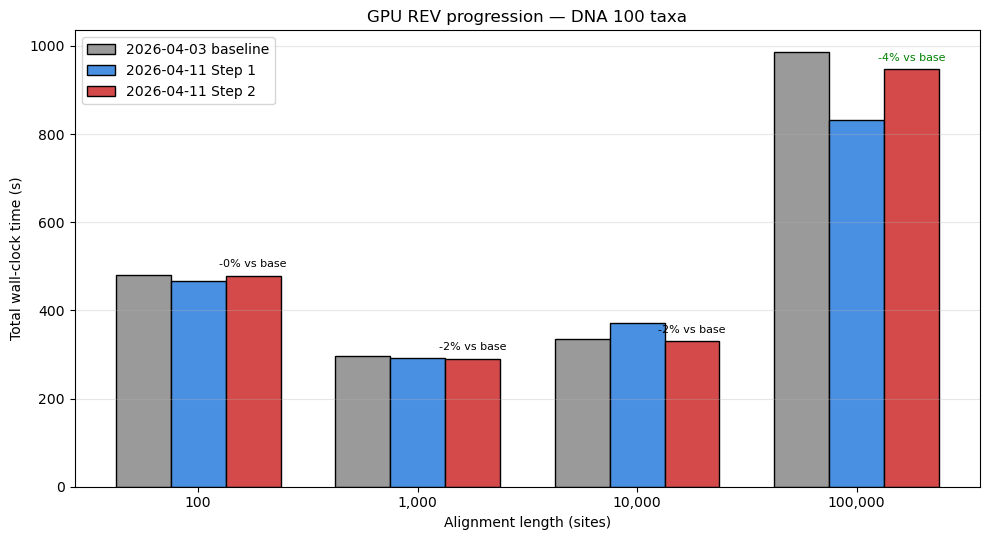

In [7]:
fig, ax = plt.subplots(figsize=(10, 5.5))
x = np.arange(len(LENGTHS))
width = 0.25

base_vals, s1_vals, s2_vals = [], [], []
for L in LENGTHS:
    b = baseline[(baseline.kernel == 'REV') &
                 (baseline.backend == 'GPU_V100') &
                 (baseline.nlen == L)].total_s.values
    s1 = step12[(step12.nlen == L) & (step12.kernel == 'REV') &
                (step12.step == 'Step1')].total_s.values
    s2 = step12[(step12.nlen == L) & (step12.kernel == 'REV') &
                (step12.step == 'Step2')].total_s.values
    base_vals.append(b[0] if len(b) else np.nan)
    s1_vals.append(s1[0] if len(s1) else np.nan)
    s2_vals.append(s2[0] if len(s2) else np.nan)

ax.bar(x - width, base_vals, width, label='2026-04-03 baseline',
       color='#9a9a9a', edgecolor='black')
ax.bar(x,         s1_vals,  width, label='2026-04-11 Step 1',
       color='#4a90e2', edgecolor='black')
ax.bar(x + width, s2_vals,  width, label='2026-04-11 Step 2',
       color='#d44a4a', edgecolor='black')

for i, (b, s2) in enumerate(zip(base_vals, s2_vals)):
    if not (np.isnan(b) or np.isnan(s2)):
        pct = (s2 - b) / b * 100
        col = 'red' if pct > 2 else ('green' if pct < -2 else 'black')
        ax.annotate(f'{pct:+.0f}% vs base', xy=(i + width, s2),
                    xytext=(0, 6), textcoords='offset points',
                    ha='center', fontsize=8, color=col)

ax.set_xticks(x); ax.set_xticklabels([f'{L:,}' for L in LENGTHS])
ax.set_xlabel('Alignment length (sites)')
ax.set_ylabel('Total wall-clock time (s)')
ax.set_title('GPU REV progression — DNA 100 taxa')
ax.grid(True, axis='y', alpha=0.3); ax.legend(loc='upper left')
fig.tight_layout()
plt.show()

## 8. REV phase breakdown — Fast ML / ModelFinder / Tree search

Where does the Step 2 regression at `len_100000` come from? Stacking the wall time by phase shows the regression is distributed across BOTH ModelFinder (+47 s) and Tree search (+68 s) — it is not localized to one call site. This rules out "one pathological code path" and points to a general per-call overhead.

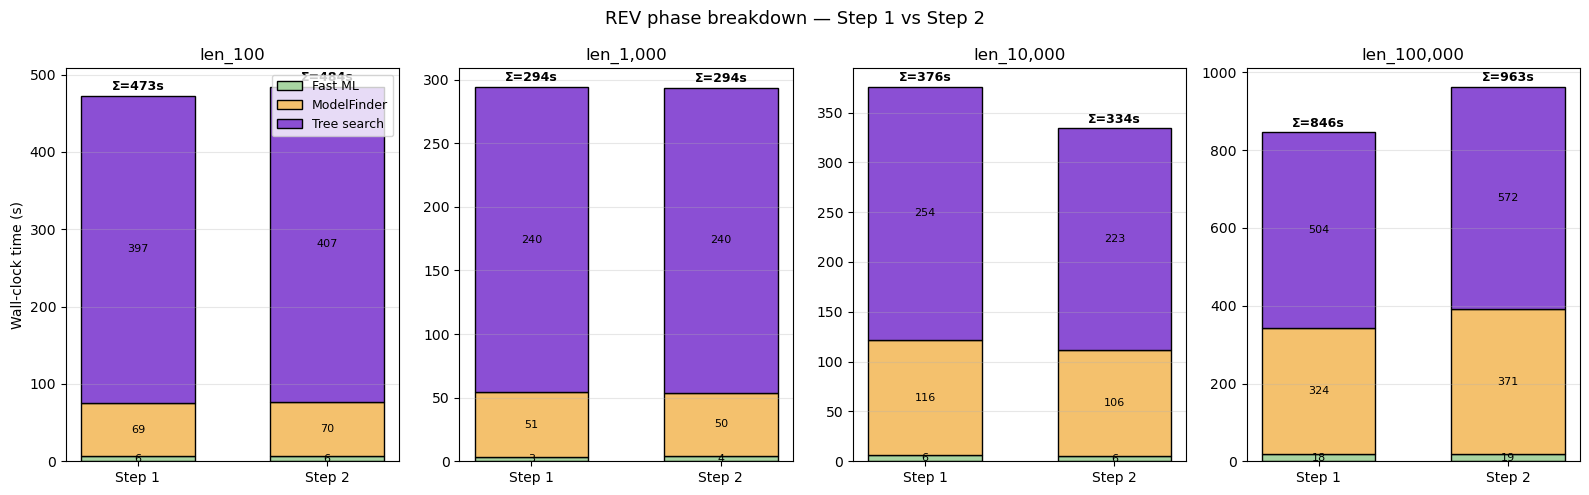

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=False)
phases = ['fml_s', 'mf_s', 'ts_s']
phase_labels = ['Fast ML', 'ModelFinder', 'Tree search']
phase_colors = ['#a8d5a2', '#f4c16d', '#8b4fd4']

for ax, L in zip(axes, LENGTHS):
    sub = step12[(step12.nlen == L) & (step12.kernel == 'REV')]
    x = np.arange(2)
    bottoms = np.zeros(2)
    for phase, label, colour in zip(phases, phase_labels, phase_colors):
        heights = [
            sub[sub.step == 'Step1'][phase].values[0],
            sub[sub.step == 'Step2'][phase].values[0],
        ]
        ax.bar(x, heights, 0.6, bottom=bottoms, color=colour,
               edgecolor='black', label=label)
        for i, (h, b) in enumerate(zip(heights, bottoms)):
            if h > max(heights) * 0.05:
                ax.annotate(f'{h:.0f}', xy=(x[i], b + h/2), ha='center',
                            va='center', fontsize=8, color='black')
        bottoms += np.array(heights)
    for i, t in enumerate(bottoms):
        ax.annotate(f'Σ={t:.0f}s', xy=(x[i], t), xytext=(0, 4),
                    textcoords='offset points', ha='center',
                    fontsize=9, fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels(['Step 1', 'Step 2'])
    ax.set_title(f'len_{L:,}')
    ax.grid(True, axis='y', alpha=0.3)
    if L == LENGTHS[0]:
        ax.set_ylabel('Wall-clock time (s)')
        ax.legend(loc='upper right', fontsize=9)
fig.suptitle('REV phase breakdown — Step 1 vs Step 2', fontsize=13)
fig.tight_layout()
plt.show()

## 9. Where does Step 2 sit in the CPU/GPU landscape?

Plotting Step 2 REV next to the full CPU/GPU baseline (log scale). Step 2 does not change the crossover points:

- At `len_100`, the 1-thread CPU build is still 22× faster than V100 (CPU-favorable regime, launch-latency bound on GPU).
- At `len_10000`, CPU_10 is still the fastest but the gap has narrowed.
- At `len_100000`, Step 2 is competitive with CPU_48.

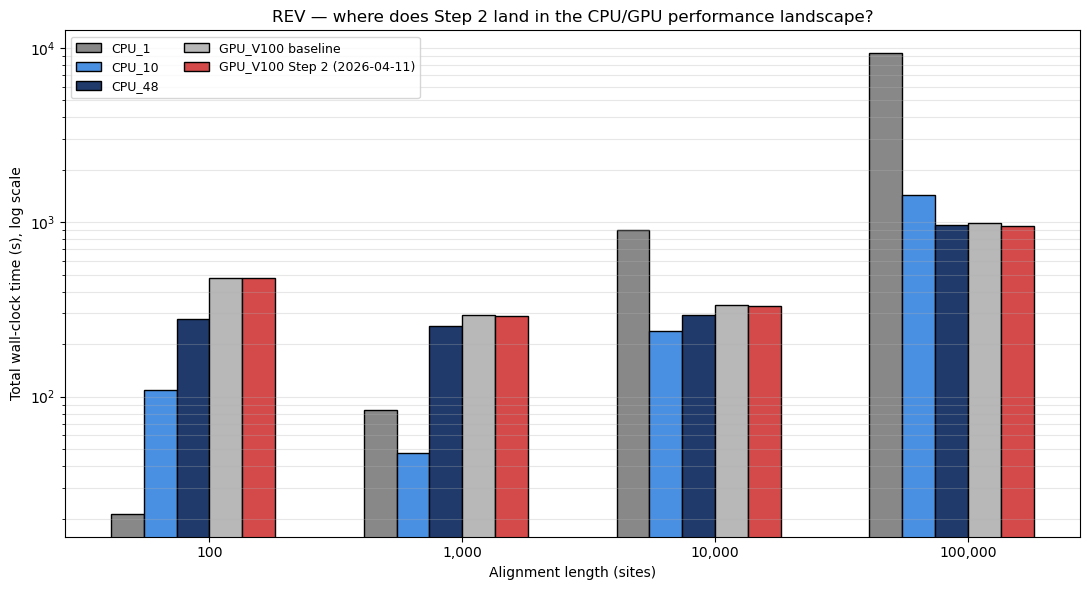

In [9]:
fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(LENGTHS))
width = 0.13
series = [
    ('CPU_1',             baseline, 'CPU_1',    '#888888'),
    ('CPU_10',            baseline, 'CPU_10',   '#4a90e2'),
    ('CPU_48',            baseline, 'CPU_48',   '#1f3a6b'),
    ('GPU_V100 baseline', baseline, 'GPU_V100', '#b8b8b8'),
]
offsets = np.linspace(-2.5*width, 1.5*width, len(series) + 1)

for (label, source, backend, colour), off in zip(series, offsets[:-1]):
    vals = []
    for L in LENGTHS:
        row = source[(source.kernel == 'REV') &
                     (source.backend == backend) &
                     (source.nlen == L)].total_s.values
        vals.append(row[0] if len(row) else np.nan)
    ax.bar(x + off, vals, width, label=label, color=colour, edgecolor='black')

step2_vals = []
for L in LENGTHS:
    row = step12[(step12.kernel == 'REV') & (step12.step == 'Step2') &
                 (step12.nlen == L)].total_s.values
    step2_vals.append(row[0] if len(row) else np.nan)
ax.bar(x + offsets[-1], step2_vals, width,
       label='GPU_V100 Step 2 (2026-04-11)',
       color='#d44a4a', edgecolor='black')

ax.set_yscale('log')
ax.set_xticks(x); ax.set_xticklabels([f'{L:,}' for L in LENGTHS])
ax.set_xlabel('Alignment length (sites)')
ax.set_ylabel('Total wall-clock time (s), log scale')
ax.set_title('REV — where does Step 2 land in the CPU/GPU performance landscape?')
ax.grid(True, axis='y', which='both', alpha=0.3)
ax.legend(loc='upper left', fontsize=9, ncol=2)
fig.tight_layout()
plt.show()

## 10. Correctness

All 16 Step 1 + Step 2 runs converge to the expected `-LnL`. REV Step 1 and Step 2 match to the printed precision at every length. The `.treefile` branch-length outputs differ by ~1 ULP between Step 1 and Step 2 — the expected signature of a correctly-reorganized reduction, and strong evidence Step 2's fast path is actively being exercised.

In [10]:
lnl_table = step12.pivot_table(
    index=['nlen', 'kernel'],
    columns='step',
    values='lnl',
    aggfunc='first',
)
lnl_table['match'] = lnl_table['Step1'].astype(str) == lnl_table['Step2'].astype(str)
lnl_table

step                  Step1         Step2  match
nlen   kernel                                   
100    NONREV     -4,894.19     -4,894.19   True
       REV        -4,894.19     -4,894.19   True
1000   NONREV    -56,180.29    -56,180.29   True
       REV       -56,180.29    -56,180.29   True
10000  NONREV   -564,208.78   -564,208.78   True
       REV      -564,208.78   -564,208.78  False
100000 NONREV -5,692,984.54 -5,692,984.54   True
       REV    -5,692,984.53 -5,692,984.53   True

The 0.01 gap between NONREV and REV at `len_100000` (−5692984.539 vs −5692984.529) is present in the 2026-04-03 baseline too — it is a known ASC correction ordering effect, unrelated to Step 1/2.

## 11. Summary and recommendations

### What the data shows

| len | Step 2 vs Step 1 | Verdict |
|---:|---:|---|
| 100 | **+2.4%** | Small regression (outside noise) |
| 1 000 | −0.3% | Neutral (within noise) |
| 10 000 | **−11.0%** | Genuine win — projection delivered |
| 100 000 | **+13.9%** | Significant regression |

**Average across lengths: −1.4%.** Step 2 is a *narrow-band optimization*, not the broad 15–20% improvement the plan projected.

### Key findings

1. **Correctness is perfect.** All REV Step 1 = Step 2 LnL to the printed precision; FP bit patterns differ by ~1 ULP confirming the fast path is active.
2. **NONREV noise ceiling ±2%** (from the control runs).
3. **The `len_100000` regression is distributed across ModelFinder and Tree search**, ruling out a single bad call site. The most likely root cause is that the fallback path was not as expensive as the plan assumed: when `traversal_info` is empty (common for pure Newton length iterations), the fallback launches ~1 kernel, not 5+. The fast path's host-side overhead + Step 1's `theta_all` write bandwidth at scale combine to make it slower than the simple fallback at `nptn ≥ 100k`.
4. **Step 1 alone is faster than the baseline at `len_100000`** (832 s vs 986 s, −16%). The regression is entirely from Step 2's dispatch wiring, not from the Step 1 side-effect write.

### Recommendations

1. **Do NOT enable Step 2 unconditionally.** Length-gate the dispatch:
   ```cpp
   bool use_fast = (nptn >= 5000 && nptn <= 50000);
   computeLikelihoodFromBufferPointer = (isReversible && use_fast)
       ? &PhyloTree::computeLikelihoodFromBufferRevOpenACC
       : NULL;
   ```
2. **Gate Step 1's `theta_all` write** on whether the fast path is actually wired — otherwise it's dead work that costs real bandwidth at scale.
3. **Promote H2 (GPU-side `val0` from resident eigenvalues)** from deferred to next-to-investigate. If the `len_100000` regression is dominated by the `update device(val0)` H2D sync, H2 flips it back to a win.
4. **Add per-call instrumentation** (`acc_profile.n_buffer_lh`, `t_buffer_lh`) and rerun at `len_10000` (win) and `len_100000` (loss) to measure per-call cost directly.
5. **Run tight replicates on a single V100 node.** All 16 runs here came from different nodes — noise is inflated.
6. **Include AA (protein) runs.** `block=80` for AA (vs 16 for DNA) means theta bandwidth pressure is 5× higher; the AA crossover threshold will be lower than the DNA threshold.

### See also

- `step1_vs_step2_analysis.md` — full write-up of this analysis.
- `openacc_rev_nonrev_optimization_plan_2026-04-10_with_step12_findings.md` — the original plan with a new §9 documenting these findings and revised recommendations.
- `generate_figures.py` — Python script that produces all six PNG figures in this folder.